<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/05_varying_intercept_slope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 5 — Varying intercepts and slopes

Let both baseline reaction time and the deprivation slope vary by participant.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

In [7]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 5.1 Participant-specific deprivation effects

Do participants differ in how strongly continued sleep deprivation affects reaction time?

$$\mu_i=(\alpha+u_{0,s[i]})+(\beta+u_{1,s[i]})\,\text{Days}_i.$$

The book's `brms` model places an LKJ prior on the correlation between participant intercept and slope deviations. We use independent priors for the two group-level effects instead — a deliberate simplification, not a software limitation — so this notebook reproduces the varying-intercept/varying-slope structure but not that correlation parameter.

In [8]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.04)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=0.10)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )

    pm.Normal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma, slope]


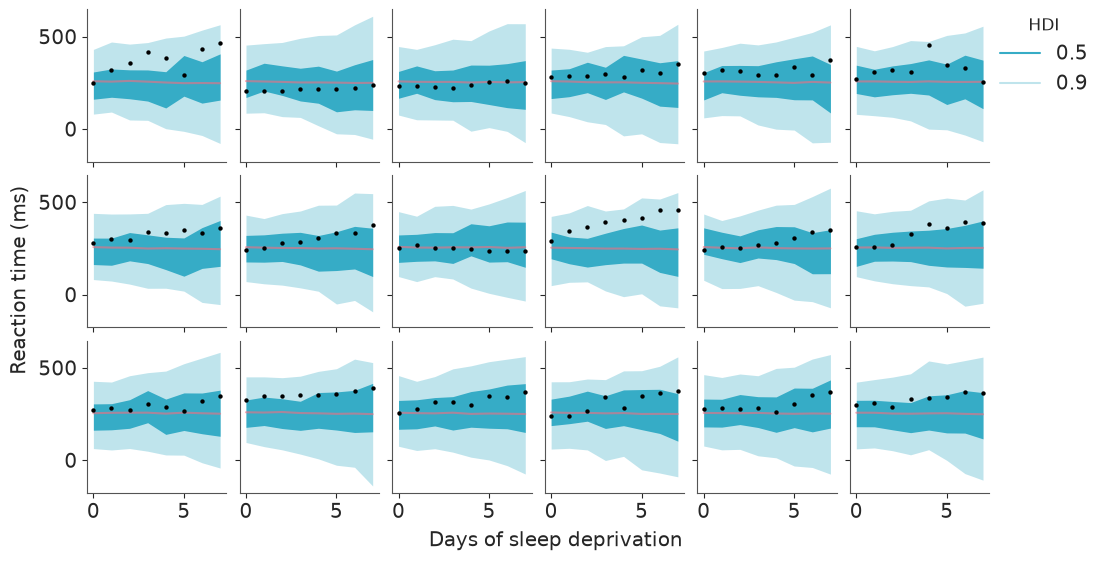

In [9]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 5.2 Individual trajectories

What population and individual trajectories are estimated when both baseline and slope partially pool?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [10]:
with model:
    idata = pm.sample(
        draws=1000, tune=1500, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd", "participant_slope_sd"],
    ci_prob=0.90, ci_kind="hdi", round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 23 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,267.68,8.56,253.94,281.38,1406.30,2065.19,1.0,0.23,0.18
slope,11.32,1.95,8.09,14.48,1698.69,2114.34,1.0,0.05,0.03
sigma,25.74,1.74,23.01,28.65,3703.90,2960.22,1.0,0.03,0.03
participant_intercept_sd,32.28,6.94,20.86,42.77,1878.03,2301.22,1.0,0.16,0.11
participant_slope_sd,7.34,1.60,4.86,9.91,1382.97,2090.64,1.0,0.04,0.03


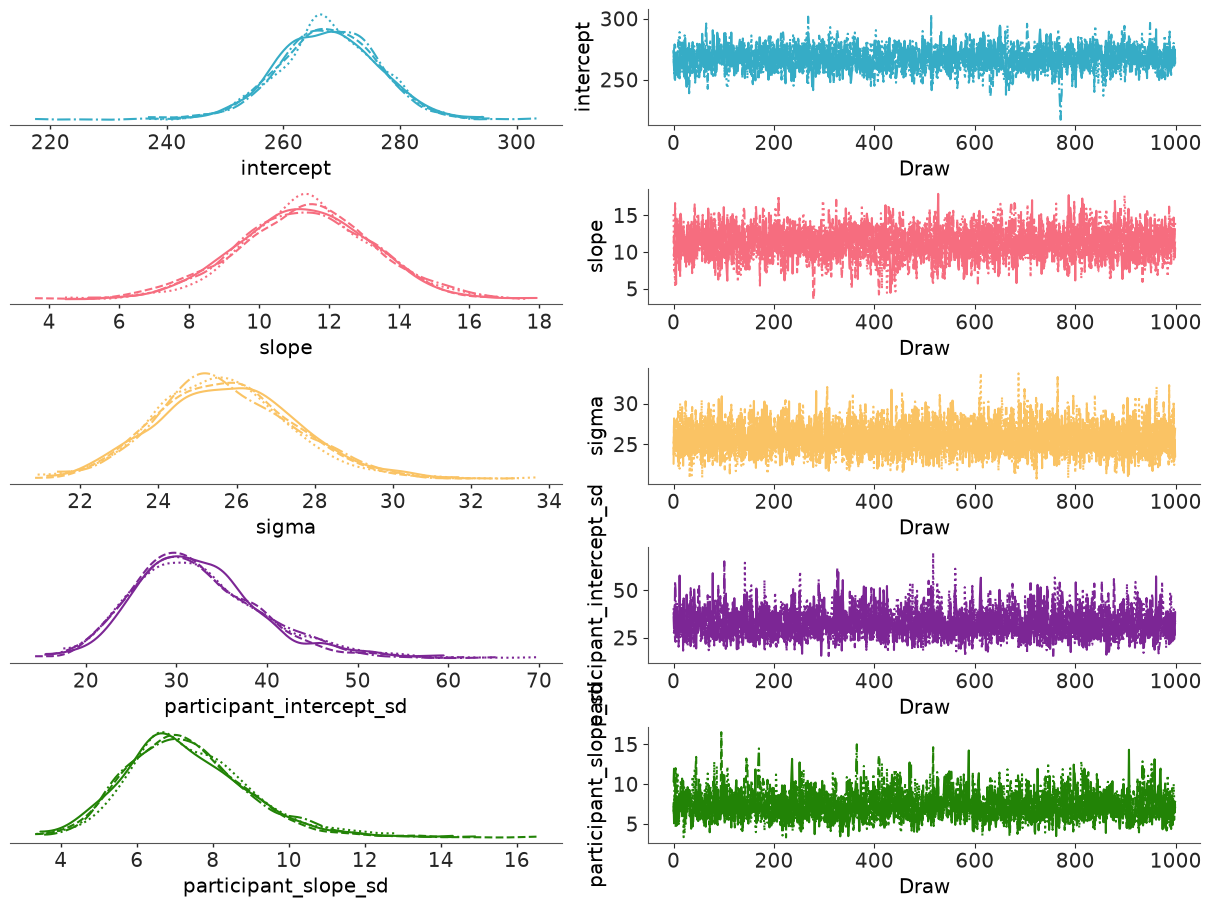

In [11]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd", "participant_slope_sd"]);

This plot shows posterior uncertainty in the expected reaction time of a *typical* participant (all participant-specific deviations set to zero). It does not include between-participant or measurement-to-measurement variation.

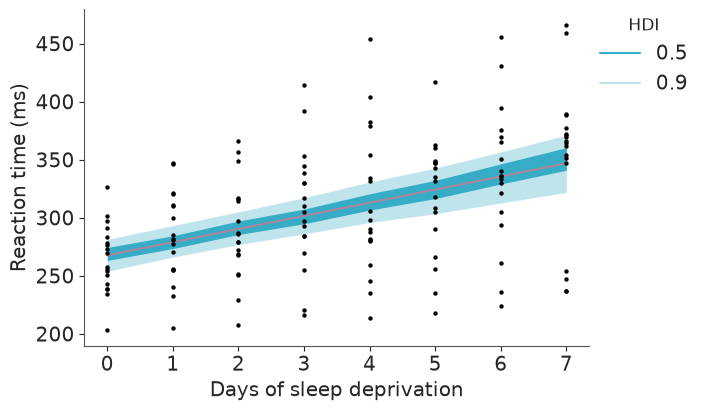

In [12]:
plot_population(idata, "population_mu")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time. These are mean trajectories, not new measurements. The next plot adds measurement variation.

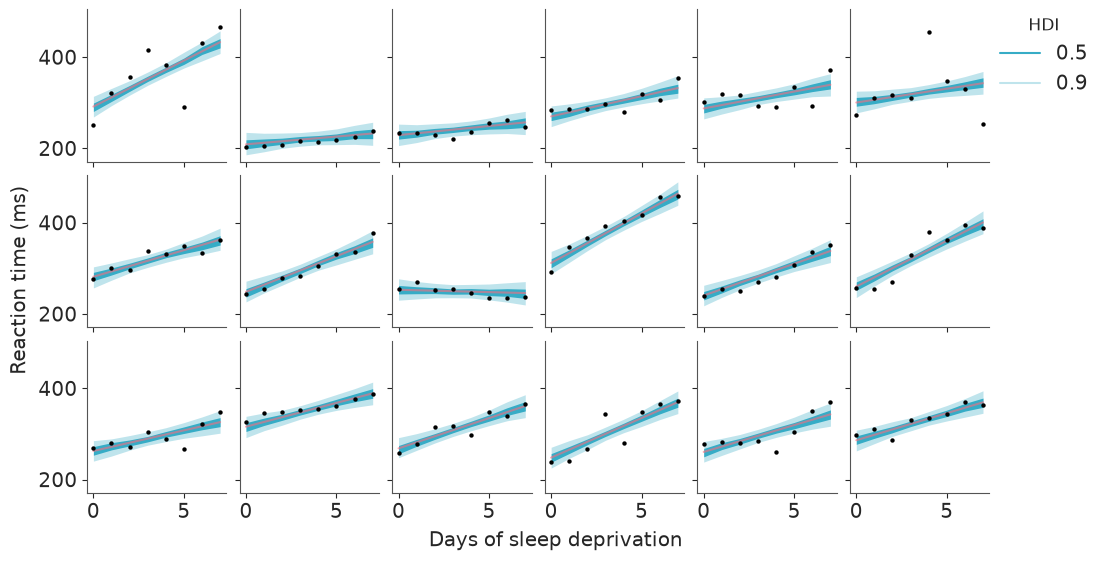

In [13]:
plot_participants(idata, "posterior", "mu")
plt.show()

## 5.3 Remaining predictive mismatch

After allowing both intercepts and slopes to vary, what predictive mismatch remains?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

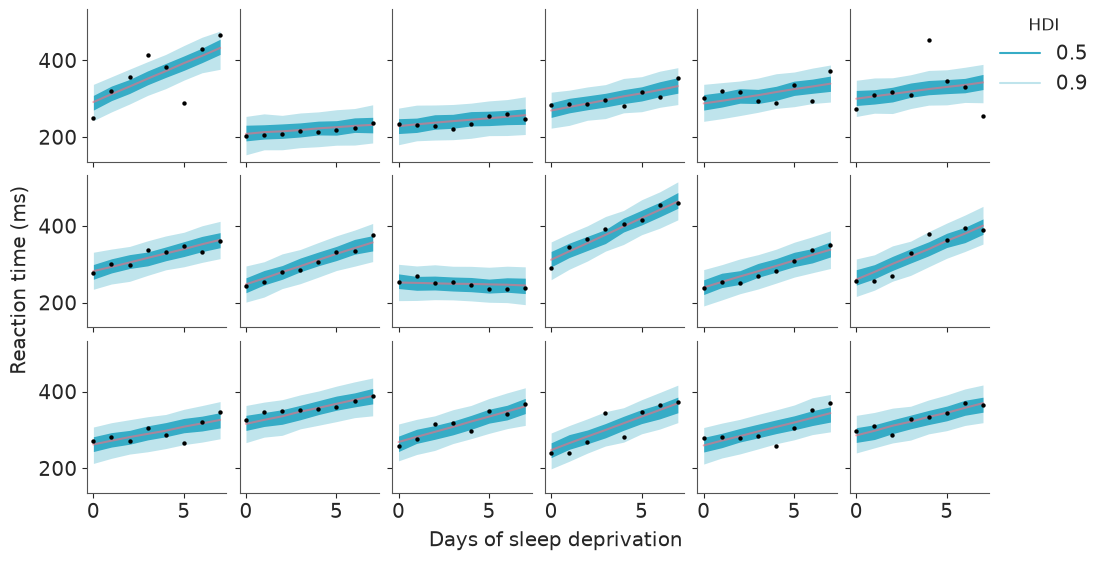

In [14]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

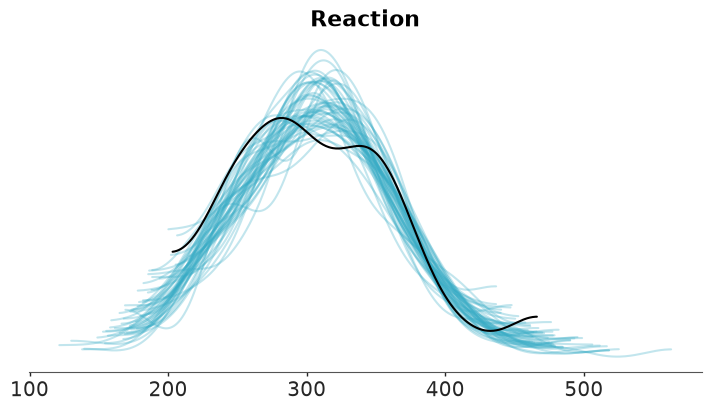

In [15]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

The hierarchical mean structure is now flexible, but reaction times are positive and right-skewed. The next branch asks whether a positive-only lognormal observation model is a useful alternative.